# Análise Exploratória dos Dados - parte 2

> **Autor**: Miguel Vieira Machado Pim  
> **Contexto**: Desafio do processo seletivo de estágio IndustriALL

Notebooks anteriores a este:

1. [`01_pre_processing`](01_pre_processing.ipynb)
2. [`02_data_visualization`](02_data_visualization.ipynb)
3. [`03_eda_part1`](03_eda_part1.ipynb)

Este notebook visa analisar valores anômalos dos sensores.

## Bibliotecas

In [1]:
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path

## Funções

In [2]:
def preprocess_data(data_path: Path) -> pd.DataFrame:
    """
    Essa função coleta todos os 53 arquivos csv e converte eles em um único dataframe final.

    Args:
        data_path (Path): Caminho para a pasta que contém os arquivos csv.

    Returns:
        pd.DataFrame: Dataframe final contendo todas as features e a coluna target.
    """
    # Coletando todos os arquivos
    feature_dfs = []
    target_df = None

    for file in data_path.glob("*.csv"):
        if "target" in file.name:
            target_df = pd.read_csv(file)
            target_df.columns = ["timestamp", "target"]
        else:
            sensor_id = int(re.search(r"\d+", file.stem).group())
            
            df = pd.read_csv(file)
            df.columns = ["timestamp", f"sensor_{sensor_id}"]

            feature_dfs.append(df)
    
    feature_dfs.sort(
        key=lambda df: int(df.columns[1].split("_")[1])
    )
    
    # Tratando tipos dos datasets
    for df in feature_dfs:
        df["timestamp"] = pd.to_datetime(df["timestamp"])
    
    target_df["target"] = target_df["target"].map({
        "NORMAL": 0,
        "ANORMAL": 1
    }).astype(int)
    target_df["timestamp"] = pd.to_datetime(target_df["timestamp"])
    
    # Construindo dataset final
    df_final = (
        pd.concat(
            [target_df.set_index("timestamp")] +
            [df.set_index("timestamp") for df in feature_dfs],
            axis=1,
            join="outer" # Para mantermos timestamps que não estão em todas as tabelas
        )
        .sort_index()
    )
    
    return df_final

In [3]:
def plotar_anomalias_no_tempo(
    df,
    variaveis,
    figsize=(18, 5)
):
    dados = df.sort_index()
    target = dados["target"]

    inicios_falha = dados.index[
        target.eq(1) & target.shift(fill_value=0).eq(0)
    ]

    finais_falha = dados.index[
        target.eq(1) & target.shift(-1, fill_value=0).eq(0)
    ]

    fig, axes = plt.subplots(
        len(variaveis),
        1,
        figsize=(figsize[0], figsize[1] * len(variaveis)),
        sharex=True
    )

    axes = [axes] if len(variaveis) == 1 else axes

    for i, (ax, variavel) in enumerate(zip(axes, variaveis)):
        anomalias = dados[variavel].eq(1)

        inicios_anomalia = dados.index[
            anomalias & ~anomalias.shift(fill_value=False)
        ]

        finais_anomalia = dados.index[
            anomalias & ~anomalias.shift(-1, fill_value=False)
        ]

        # Ponto central de cada período anômalo
        pontos_anomalia = (
            inicios_anomalia
            + (finais_anomalia - inicios_anomalia) / 2
        )

        ax.fill_between(
            dados.index,
            0,
            1,
            where=anomalias,
            step="post",
            alpha=0.8
        )

        ax.scatter(
            pontos_anomalia,
            [1.03] * len(pontos_anomalia),
            color="red",
            s=25,
            zorder=5,
            clip_on=False,
            label="Período anômalo" if i == 0 else None
        )

        for inicio in inicios_falha:
            ax.axvline(
                inicio,
                color="red",
                linestyle="--",
                linewidth=1,
                label="Início da falha" if i == 0 and inicio == inicios_falha[0] else None
            )

        for fim in finais_falha:
            ax.axvline(
                fim,
                color="black",
                linestyle=":",
                linewidth=1,
                label="Fim da falha" if i == 0 and fim == finais_falha[0] else None
            )

        ax.set_yticks([0, 1])
        ax.set_yticklabels(["NORMAL", "ANOMALIA"])
        ax.set_ylim(-0.05, 1.08)

        ax.set_title(
            f"{variavel} — "
            f"{len(pontos_anomalia):,} períodos anômalos | "
            f"{anomalias.sum():,} registros ({anomalias.mean():.2%})"
        )

    axes[0].legend(loc="upper right")
    axes[-1].set_xlabel("Timestamp")

    fig.suptitle(
        "Anomalias dos sensores e falhas ao longo do tempo",
        y=1
    )

    plt.tight_layout()
    plt.show()

In [4]:
def obter_sensores(df):
    return sorted(
        df.filter(regex=r"^sensor_\d+$").columns,
        key=lambda x: int(x.split("_")[1])
    )


def converter_target(target):
    return (
        target.astype(str)
        .str.upper()
        .isin(["1", "ANORMAL", "TRUE"])
    )


def obter_eventos_falha(df, target_col="target"):
    dados = df.sort_index()
    falha = converter_target(dados[target_col])

    inicios = dados.index[
        falha & ~falha.shift(fill_value=False)
    ]

    finais = dados.index[
        falha & ~falha.shift(-1, fill_value=False)
    ]

    frequencia = dados.index.to_series().diff().median()

    return pd.DataFrame({
        "evento": range(1, len(inicios) + 1),
        "inicio": inicios,
        "fim": finais,
        "duracao": finais - inicios + frequencia
    })

In [5]:
def criar_ranking_sensores(
    df_anomalias,
    horas_antes=4
):
    dados = df_anomalias.sort_index()
    sensores = obter_sensores(dados)
    eventos = obter_eventos_falha(dados)

    frequencia_min = (
        dados.index.to_series()
        .diff()
        .median()
        .total_seconds() / 60
    )

    janela_relevante = pd.Series(
        False,
        index=dados.index
    )

    resultados = []

    for sensor in sensores:
        falhas_detectadas = 0
        antecedencias = []
        persistencias = []

        for _, evento in eventos.iterrows():
            inicio = evento["inicio"]
            fim = evento["fim"]

            mascara_antes = (
                (dados.index >= inicio - pd.Timedelta(hours=horas_antes))
                & (dados.index < inicio)
            )

            mascara_relevante = (
                (dados.index >= inicio - pd.Timedelta(hours=horas_antes))
                & (dados.index <= fim)
            )

            janela_relevante |= mascara_relevante

            serie = dados.loc[mascara_antes, sensor].eq(1)

            if serie.any():
                falhas_detectadas += 1

                primeira_anomalia = serie[serie].index.min()

                antecedencias.append(
                    (inicio - primeira_anomalia)
                    .total_seconds() / 60
                )

                persistencias.append(
                    serie.sum() * frequencia_min
                )

        fora_janela = ~janela_relevante
        total_anomalias = dados[sensor].sum()

        anomalias_fora = dados.loc[
            fora_janela,
            sensor
        ].sum()

        anomalias_proximas = dados.loc[
            janela_relevante,
            sensor
        ].sum()

        cobertura = (
            falhas_detectadas / len(eventos) * 100
        )

        taxa_fora = (
            dados.loc[fora_janela, sensor].mean() * 100
        )

        proximidade = (
            anomalias_proximas / total_anomalias * 100
            if total_anomalias > 0
            else 0
        )

        score = (
            cobertura
            * (proximidade / 100)
            * (1 - taxa_fora / 100)
        )

        resultados.append({
            "sensor": sensor,
            "falhas_detectadas": falhas_detectadas,
            "cobertura_falhas_pct": cobertura,
            "antecedencia_mediana_min": (
                np.median(antecedencias)
                if antecedencias else np.nan
            ),
            "persistencia_mediana_min": (
                np.median(persistencias)
                if persistencias else 0
            ),
            "anomalias_fora_janelas": anomalias_fora,
            "taxa_anomalia_fora_pct": taxa_fora,
            "anomalias_proximas_falhas_pct": proximidade,
            "score": score
        })

    return (
        pd.DataFrame(resultados)
        .sort_values("score", ascending=False)
        .reset_index(drop=True)
    )

In [6]:
def criar_matriz_sensor_evento(
    df_anomalias,
    minutos_antes=60,
    periodo="antes"
):
    dados = df_anomalias.sort_index()
    sensores = obter_sensores(dados)
    eventos = obter_eventos_falha(dados)

    resultado = {}

    for _, evento in eventos.iterrows():
        inicio = evento["inicio"]
        fim = evento["fim"]

        if periodo == "antes":
            janela = dados.loc[
                inicio - pd.Timedelta(minutes=minutos_antes):
                inicio
            ].iloc[:-1]

        elif periodo == "durante":
            janela = dados.loc[inicio:fim]

        elif periodo == "antes_e_durante":
            janela = dados.loc[
                inicio - pd.Timedelta(minutes=minutos_antes):
                fim
            ]

        resultado[f"Falha {evento['evento']}"] = (
            janela[sensores].mean() * 100
        )

    return pd.DataFrame(resultado)

def plotar_heatmap_sensor_evento(
    matriz,
    titulo,
    figsize=(6, 6)
):
    fig, ax = plt.subplots(figsize=figsize)

    sns.heatmap(
        matriz,
        cmap="Reds",
        vmin=0,
        vmax=100,
        ax=ax,
        cbar_kws={
            "label": "% de registros anômalos"
        }
    )

    ax.set_title(titulo)
    ax.set_xlabel("Evento de falha")
    ax.set_ylabel("Sensor")

    plt.tight_layout()
    plt.show()

## Carregando os dados

In [7]:
data_path = Path("../data")

industry_df = preprocess_data(data_path)

In [8]:
eda_df = industry_df.copy()
eda_df

,target,sensor_0,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,...,sensor_42,sensor_43,sensor_44,sensor_45,sensor_46,sensor_47,sensor_48,sensor_49,sensor_50,sensor_51
timestamp,,,,,,,,,,,,,,,,,,,,,
2018-04-01 00:00:00,0,4.548754,90.886874,58.698896,89.301134,1011.733181,97.284889,33.248746,-10.390227,29.262578,...,101.547023,154.291476,114.466107,103.082616,119.246973,60.729332,310.022461,124.735196,426.651658,410.820484
2018-04-01 00:01:00,0,7.887998,56.555373,80.802810,120.898222,1358.466600,202.583688,32.494870,19.427739,61.038519,...,71.846296,59.239207,90.076161,93.760055,63.457947,62.910653,306.084796,158.822485,375.316113,143.620728
2018-04-01 00:02:00,0,4.975919,182.086958,87.273632,9.914782,1056.489015,147.098428,36.402837,38.900027,30.304666,...,59.174616,87.136301,99.274584,111.916792,60.560834,81.332910,353.863854,88.772027,444.809188,618.898000
2018-04-01 00:03:00,0,6.304142,58.417235,75.059520,64.167463,1619.924847,307.722320,34.283344,46.602862,44.859311,...,0.674927,110.321579,103.978381,103.705604,24.141894,36.219671,301.563110,53.387484,414.052496,427.323378
2018-04-01 00:04:00,0,1.671733,108.946809,94.910470,14.551922,591.648283,-7.684779,30.980682,39.293311,1.229287,...,71.785623,112.435498,103.170425,110.566095,53.913605,116.770552,298.957820,168.746952,431.548430,514.659884
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-08-31 23:55:00,0,6.066461,128.157145,144.452803,66.621842,1791.181163,172.833101,13.116142,52.438915,32.694638,...,77.001917,105.953758,169.203415,74.959180,159.206995,98.736928,432.326663,199.902569,NaN,343.198701
2018-08-31 23:56:00,0,4.057784,-31.186502,49.775117,69.397205,1166.424000,146.161645,26.785100,17.436183,39.612008,...,32.268873,12.201309,59.127149,149.304241,26.936970,125.800942,402.294815,218.904951,NaN,381.082811
2018-08-31 23:57:00,0,6.751912,80.433446,107.038506,137.923928,1060.918628,106.901675,37.495990,20.406074,33.073722,...,87.497962,90.664739,144.615688,29.140853,118.974814,75.747273,269.339456,260.899365,NaN,452.482461


## Detectando anomalias

Para cada sensor, será utilizado o **Z-score robusto**, calculado com mediana e MAD (desvio absoluto mediano). Essas medidas são menos afetadas por valores extremos do que média e desvio-padrão, uma vez que observamos no notebook [02_data_visualization](02_data_visualization.ipynb) que existem valores **muito** altos para os sensores.

Um timestamp é marcado como anômalo quando o valor do sensor está muito distante do comportamento típico da própria série.

Nesta análise:

- `0`: valor normal;
- `1`: valor anômalo;
- `n_sensores_anomalos`: quantidade de sensores anômalos no timestamp;
- `tem_anomalia`: indica se pelo menos um sensor apresentou anomalia.

Uma anomalia de sensor não representa necessariamente uma falha da máquina. Os períodos de falha são identificados separadamente pela variável `target`.

In [9]:
def criar_df_anomalias(df, limite=6):
    sensor_cols = sorted(
        df.filter(regex=r"^sensor_\d+$").columns,
        key=lambda x: int(x.split("_")[1])
    )

    X = df[sensor_cols]

    mediana = X.median()
    mad = X.sub(mediana).abs().median()

    # Escala robusta equivalente ao desvio-padrão
    escala = 1.4826 * mad

    # Sensores com MAD igual a zero usam o desvio-padrão
    escala = escala.mask(escala.eq(0), X.std())

    robust_z = X.sub(mediana).div(escala)

    df_anomalias = robust_z.abs().gt(limite).astype("int8")

    df_anomalias["n_sensores_anomalos"] = (
        df_anomalias[sensor_cols].sum(axis=1)
    )

    df_anomalias["tem_anomalia"] = (
        df_anomalias["n_sensores_anomalos"] > 0
    ).astype("int8")

    df_anomalias["target"] = df["target"]

    return df_anomalias

In [10]:
df_anomalias = criar_df_anomalias(
    industry_df,
    limite=6
)

df_anomalias.head()

,sensor_0,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,...,sensor_45,sensor_46,sensor_47,sensor_48,sensor_49,sensor_50,sensor_51,n_sensores_anomalos,tem_anomalia,target
timestamp,,,,,,,,,,,,,,,,,,,,,
2018-04-01 00:00:00,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2018-04-01 00:01:00,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2018-04-01 00:02:00,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2018-04-01 00:03:00,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2018-04-01 00:04:00,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [11]:
def resumir_periodos_anomalos(df_anomalias):

    sensor_cols = df_anomalias.filter(
        regex=r"^sensor_\d+$"
    ).columns

    mask = df_anomalias["tem_anomalia"].eq(1)

    inicio_periodo = mask & ~mask.shift(fill_value=False)
    periodo_id = inicio_periodo.cumsum()

    frequencia = (
        df_anomalias.index
        .to_series()
        .diff()
        .median()
    )

    periodos = []

    for _, trecho in df_anomalias.loc[mask].groupby(periodo_id[mask]):

        inicio = trecho.index.min()
        fim = trecho.index.max()

        sensores = [
            sensor
            for sensor in sensor_cols
            if trecho[sensor].any()
        ]

        periodos.append({
            "inicio": inicio,
            "fim": fim,
            "duracao": fim - inicio + frequencia,
            "max_sensores_simultaneos":
                trecho["n_sensores_anomalos"].max(),
            "qtd_sensores_envolvidos": len(sensores),
            "sensores_envolvidos": sensores
        })

    return pd.DataFrame(periodos)

In [12]:
periodos_anomalia = resumir_periodos_anomalos(
    df_anomalias
)

periodos_anomalia

,inicio,fim,duracao,max_sensores_simultaneos,qtd_sensores_envolvidos,sensores_envolvidos
0,2018-04-06 03:41:00,2018-04-06 03:41:00,0 days 00:01:00,1,1,[sensor_46]
1,2018-04-06 03:43:00,2018-04-06 03:46:00,0 days 00:04:00,1,1,[sensor_46]
2,2018-04-06 03:48:00,2018-04-06 03:50:00,0 days 00:03:00,1,1,[sensor_46]
3,2018-04-06 04:22:00,2018-04-06 04:23:00,0 days 00:02:00,1,1,[sensor_13]
4,2018-04-08 05:47:00,2018-04-08 05:47:00,0 days 00:01:00,1,1,[sensor_46]
...,...,...,...,...,...,...
335,2018-08-26 23:38:00,2018-08-26 23:39:00,0 days 00:02:00,1,1,[sensor_44]
336,2018-08-26 23:45:00,2018-08-26 23:45:00,0 days 00:01:00,1,1,[sensor_49]
337,2018-08-29 01:24:00,2018-08-29 01:24:00,0 days 00:01:00,1,1,[sensor_45]
338,2018-08-29 01:28:00,2018-08-29 01:28:00,0 days 00:01:00,1,1,[sensor_45]


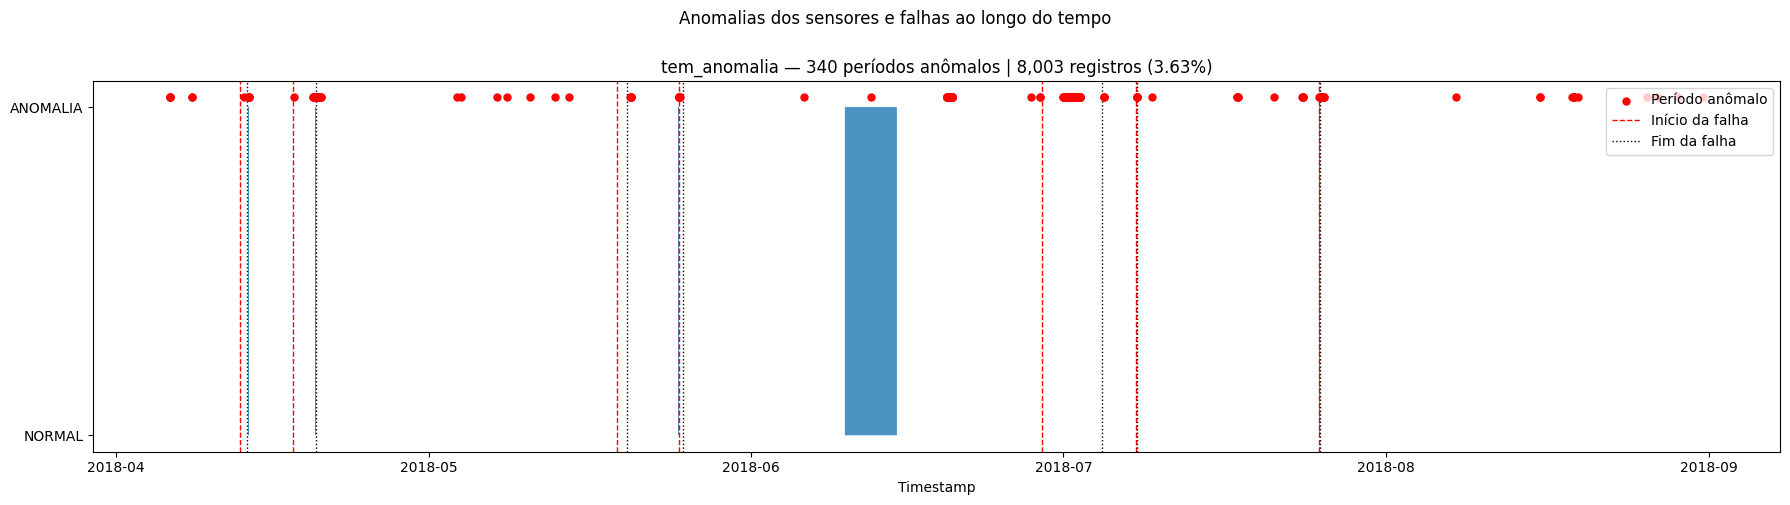

In [13]:
plotar_anomalias_no_tempo(
    df_anomalias,
    ["tem_anomalia"]
)

## Análise de anomalias em períodos anteriores a falhas

Análise com 30 minutos de antecedência

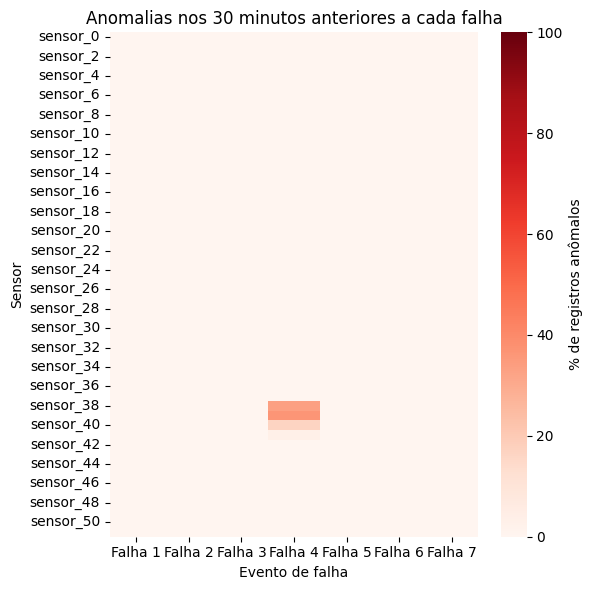

In [14]:
matriz_antes = criar_matriz_sensor_evento(
    df_anomalias,
    minutos_antes=30,
    periodo="antes"
)

plotar_heatmap_sensor_evento(
    matriz_antes,
    "Anomalias nos 30 minutos anteriores a cada falha"
)

Análise com **1 hora** de antecedência.

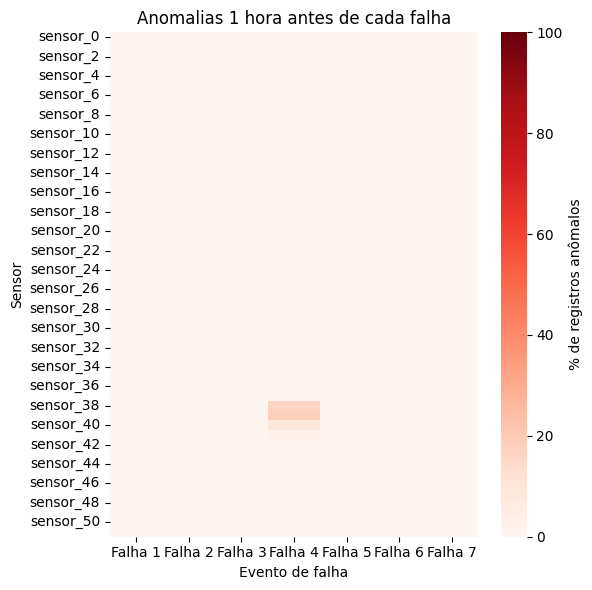

In [15]:
matriz_antes = criar_matriz_sensor_evento(
    df_anomalias,
    minutos_antes=60,
    periodo="antes"
)

plotar_heatmap_sensor_evento(
    matriz_antes,
    "Anomalias 1 hora antes de cada falha"
)

Análise com **2 horas** de antecedência.

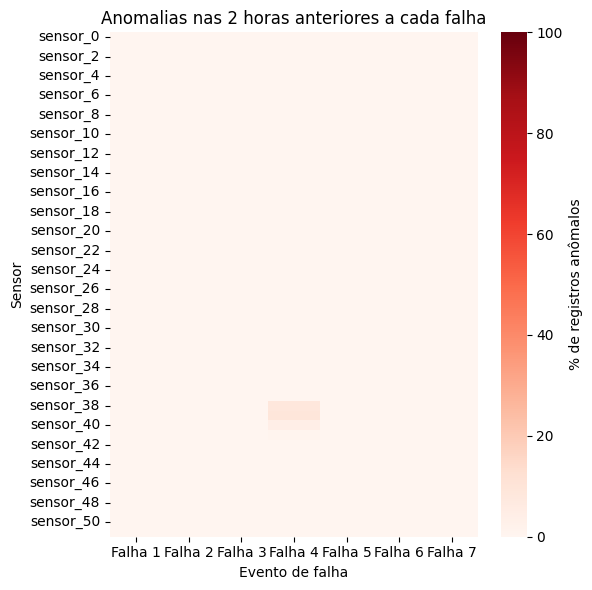

In [16]:
matriz_antes = criar_matriz_sensor_evento(
    df_anomalias,
    minutos_antes=2 * 60,
    periodo="antes"
)

plotar_heatmap_sensor_evento(
    matriz_antes,
    "Anomalias nas 2 horas anteriores a cada falha"
)

## Análise de anomalias dos sensores durante a falha

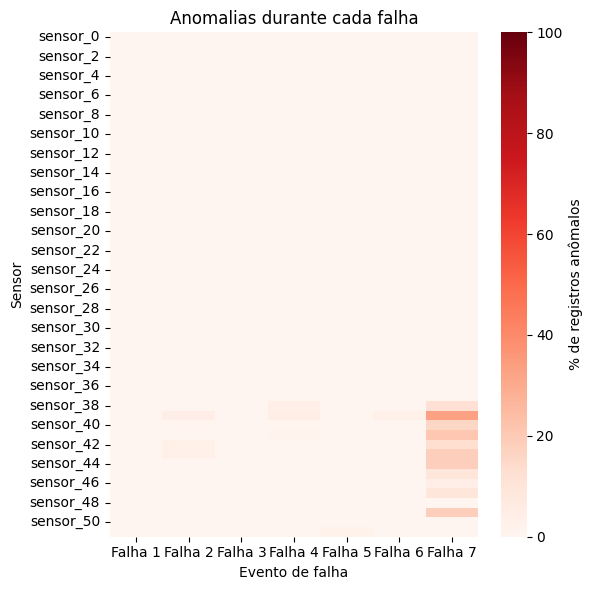

In [17]:
matriz_durante = criar_matriz_sensor_evento(
    df_anomalias,
    periodo="durante"
)

plotar_heatmap_sensor_evento(
    matriz_durante,
    "Anomalias durante cada falha"
)

In [18]:
ranking_sensores = criar_ranking_sensores(
    df_anomalias,
    horas_antes=4
)

ranking_sensores.head(15)

,sensor,falhas_detectadas,cobertura_falhas_pct,antecedencia_mediana_min,persistencia_mediana_min,anomalias_fora_janelas,taxa_anomalia_fora_pct,anomalias_proximas_falhas_pct,score
0,sensor_38,1,14.285714,11.0,10.0,699,0.342385,5.668016,0.806944
1,sensor_39,1,14.285714,11.0,11.0,7339,3.594800,2.549462,0.351116
2,sensor_46,1,14.285714,222.0,2.0,789,0.386469,2.230483,0.317409
3,sensor_40,1,14.285714,10.0,5.0,3552,1.739846,1.415487,0.198694
4,sensor_41,1,14.285714,10.0,1.0,3568,1.747683,0.751043,0.105417
5,sensor_4,0,0.000000,NaN,0.0,371,0.181724,0.000000,0.000000
6,sensor_6,0,0.000000,NaN,0.0,3836,1.878955,0.000000,0.000000
7,sensor_5,0,0.000000,NaN,0.0,7200,3.526715,0.000000,0.000000
8,sensor_8,0,0.000000,NaN,0.0,7200,3.526715,0.000000,0.000000
9,sensor_9,0,0.000000,NaN,0.0,3763,1.843198,0.000000,0.000000


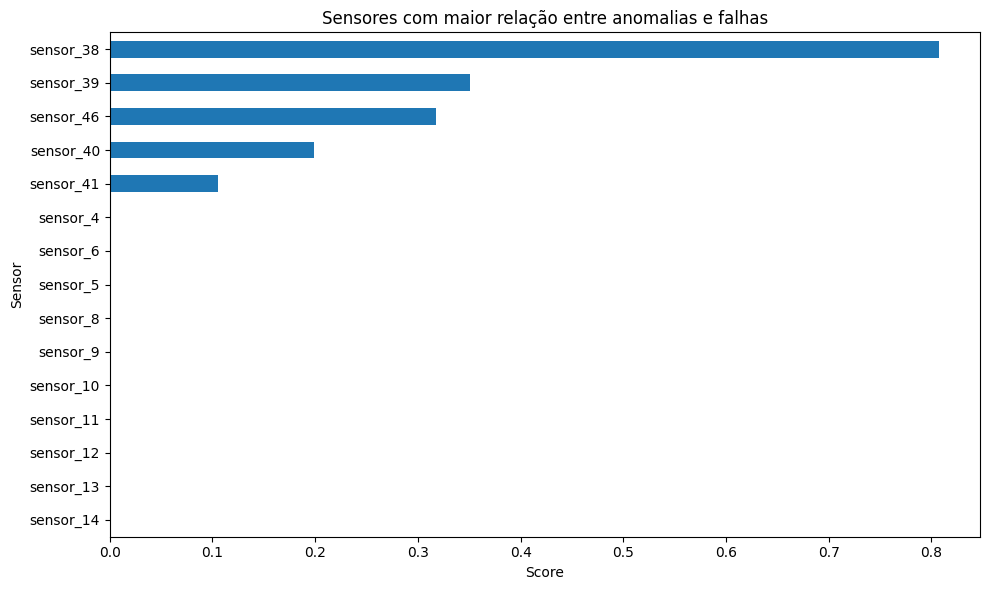

In [19]:
ranking_sensores.head(15).plot.barh(
    x="sensor",
    y="score",
    figsize=(10, 6),
    legend=False,
    title="Sensores com maior relação entre anomalias e falhas"
)

plt.xlabel("Score")
plt.ylabel("Sensor")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()